In [1]:
from google.colab import files

uploaded = files.upload()


Saving emails.csv to emails.csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report


In [4]:
df = pd.read_csv('emails.csv')

df.head()


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [5]:
print(df.columns)

Index(['text', 'spam'], dtype='object')


In [6]:
df.info()

df.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
5,"Subject: great nnews hello , welcome to medzo...",1
6,Subject: here ' s a hot play in motion homela...,1
7,Subject: save your money buy getting this thin...,1
8,Subject: undeliverable : home based business f...,1
9,Subject: save your money buy getting this thin...,1


In [8]:
print(df.shape)

print(df.isnull().sum())

(5728, 2)
text    0
spam    0
dtype: int64


In [9]:
X = df['text']
y = df['spam']

In [10]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [13]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy*100,"%")

Accuracy = 89.79057591623037 %


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       856
           1       1.00      0.60      0.75       290

    accuracy                           0.90      1146
   macro avg       0.94      0.80      0.84      1146
weighted avg       0.91      0.90      0.89      1146



In [15]:
email = [
    "Congratulations! You have won a free iPhone. Click here to claim your prize."
]

email_vector = vectorizer.transform(email)

prediction = model.predict(email_vector)

if prediction[0] == 1:
    print("SPAM EMAIL")
else:
    print("NOT SPAM EMAIL")

NOT SPAM EMAIL


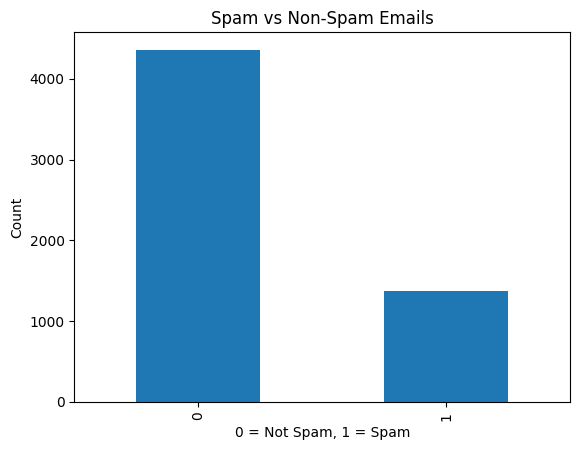

In [16]:
import matplotlib.pyplot as plt

df['spam'].value_counts().plot(kind='bar')

plt.title("Spam vs Non-Spam Emails")
plt.xlabel("0 = Not Spam, 1 = Spam")
plt.ylabel("Count")

plt.show()

In [17]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

print("Model Saved Successfully")

Model Saved Successfully
